In [1]:
##import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# 6 * np.random.rand(100, 1) - 3

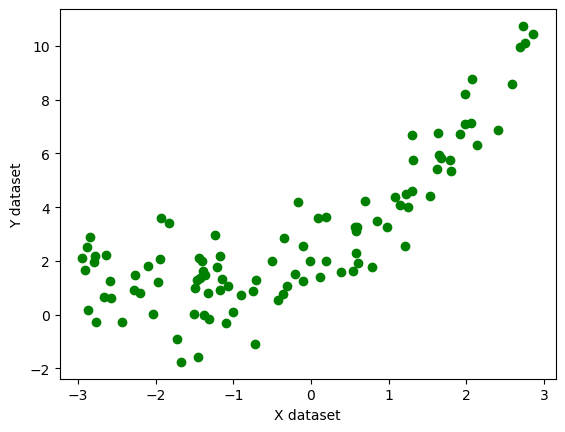

In [3]:
X = 6 * np.random.rand(100, 1) - 3
y =0.5 * X**2 + 1.5*X + 2 + np.random.randn(100, 1)
# quadratic equation used- y=0.5x^2+1.5x+2+outliers
plt.scatter(X,y,color='g')
plt.xlabel('X dataset')
plt.ylabel('Y dataset')
plt.show()

In [25]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [5]:
## Lets implement Simple Linear Regression
from sklearn.linear_model import LinearRegression
regression_1=LinearRegression()

In [6]:
regression_1.fit(X_train,y_train)

LinearRegression()

In [7]:
from sklearn.metrics import r2_score
score=r2_score(y_test,regression_1.predict(X_test))
print(score)

0.5295248647419484


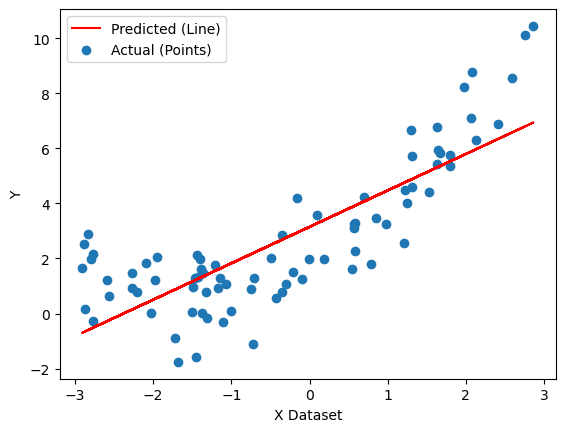

In [8]:
## Lets visualize this model
plt.plot(X_train,regression_1.predict(X_train),color='r',label='Predicted (Line)')
plt.scatter(X_train,y_train,label='Actual (Points)')
plt.xlabel("X Dataset")
plt.ylabel("Y")
plt.legend()
plt.show()

In [9]:
#Lets apply Polynomial transformation
from sklearn.preprocessing import PolynomialFeatures

In [10]:
X_train[0]

array([-1.20870954])

In [13]:
(X_train[0] ** 1) * 1

array([-1.20870954])

In [14]:
poly=PolynomialFeatures(degree=2,include_bias=True)
X_train_poly_2=poly.fit_transform(X_train)
X_test_poly_2=poly.transform(X_test)

In [15]:
X_train_poly_2[:3]

array([[ 1.        , -1.20870954,  1.46097875],
       [ 1.        , -2.79088947,  7.78906406],
       [ 1.        ,  0.58816394,  0.34593682]])

In [16]:
X_test_poly_2[:3]

array([[ 1.        , -1.23632714,  1.52850479],
       [ 1.        , -0.09782736,  0.00957019],
       [ 1.        , -2.66798551,  7.11814666]])

In [17]:
from sklearn.metrics import r2_score
regression = LinearRegression()
regression.fit(X_train_poly_2, y_train)
y_pred = regression.predict(X_test_poly_2)
score=r2_score(y_test,y_pred)
print(score)

0.8046296083666711


In [16]:
# y=0.5x^2+1.5x+2+outliers

In [18]:
print(regression.coef_)

[[0.         1.51378313 0.48847116]]


In [19]:
print(regression.intercept_)

[1.8720869]


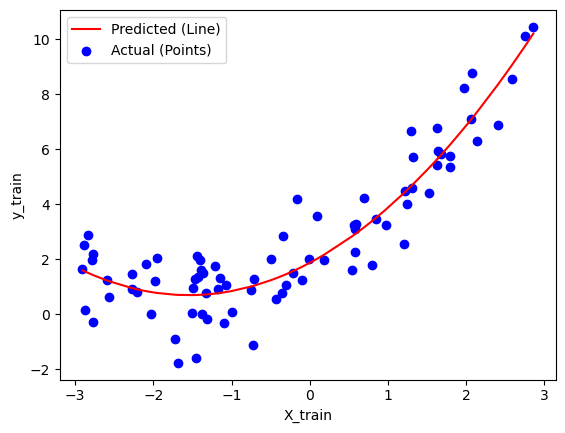

In [20]:
X_sorted = np.sort(X_train, axis=0)
y_pred_sorted = regression.predict(poly.transform(X_sorted))

plt.plot(X_sorted, y_pred_sorted, color='red', label='Predicted (Line)')
plt.scatter(X_train, y_train, color='blue', label='Actual (Points)')

plt.xlabel("X_train")
plt.ylabel("y_train")
plt.legend()
plt.show()

In [27]:
poly=PolynomialFeatures(degree=3,include_bias=True)
X_train_poly_3=poly.fit_transform(X_train)
X_test_poly_3=poly.transform(X_test)

In [28]:
(X_train[0] ** 3) * 1000

array([-1765.89894862])

In [29]:
X_train_poly_3[:3]

array([[  1.        ,  -1.20870954,   1.46097875,  -1.76589895],
       [  1.        ,  -2.79088947,   7.78906406, -21.73841689],
       [  1.        ,   0.58816394,   0.34593682,   0.20346756]])

In [31]:
from sklearn.metrics import r2_score
regression = LinearRegression()
regression.fit(X_train_poly_3, y_train)
y_pred = regression.predict(X_test_poly_3)
score=r2_score(y_test,y_pred)
print(score)

0.8001132170028596


In [32]:
#3 Prediction of new data set
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
X_new_poly

array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00,
        -2.70000000e+01],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00,
        -2.61940839e+01],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00,
        -2.54043665e+01],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00,
        -2.46306834e+01],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00,
        -2.38728702e+01],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00,
        -2.31307624e+01],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00,
        -2.24041955e+01],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00,
        -2.16930052e+01],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00,
        -2.09970269e+01],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00,
        -2.03160961e+01],
       [ 1.00000000e+00, -2.69849246e+00,  7.28186157e+00,
        -1.96500486e+01],
       [ 1.00000000e+00, -2.66834171e+00,  7.12004747e+00,
      

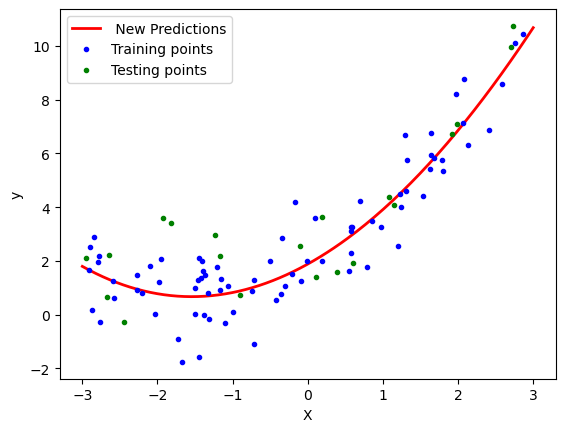

In [33]:
y_new = regression.predict(X_new_poly)
plt.plot(X_new, y_new, "r-", linewidth=2, label=" New Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

### Pipeline Concepts

In [36]:
from sklearn.pipeline import Pipeline

In [37]:

def poly_regression(degree):
    X_new = np.linspace(-3, 3, 200).reshape(200, 1)
    
    
    poly_features=PolynomialFeatures(degree=degree,include_bias=True)
    lin_reg=LinearRegression()
    poly_regression=Pipeline([
        ("poly_features",poly_features),
        ("lin_reg",lin_reg)
    ])
    poly_regression.fit(X_train,y_train) ## ploynomial and fit of linear reression
    y_pred_new=poly_regression.predict(X_new)
    
    
    #plotting prediction line
    plt.plot(X_new, y_pred_new,'r', label="Degree " + str(degree), linewidth=2)
    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-4,4, 0, 10])
    plt.show()

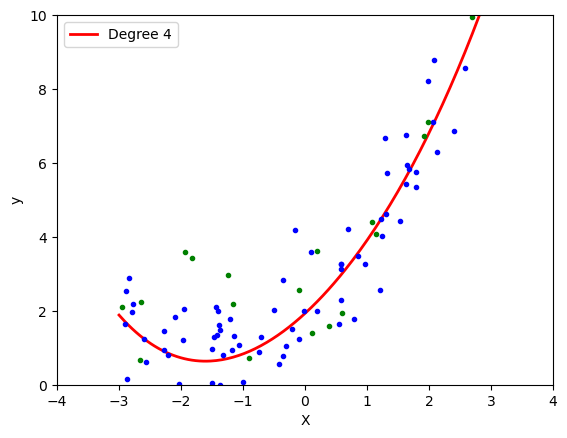

In [40]:
poly_regression(4)